# Imprimir circuitos de cobre a 150 °C

**150 °C.** Esa es la temperatura a la que un equipo logró fundir nanopartículas de cobre en un conductor con resistividad **12,8 µΩ·cm** — cuatro veces mejor que cualquier otro método que opere por debajo de 150 °C, y muy por debajo de la mediana de 250 °C que pide la literatura. La clave: catecoles. La misma familia química que la dopamina.

📄 **Paper:** [A molecular pathway to corrosion-resistant printable copper](https://doi.org/10.1126/science.aed4488) · *Science, 2026*

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-14-cobre-corrosion-catecol/notebook.ipynb)


## Por qué importa

El cobre conduce electricidad casi tan bien como la plata, pero cuesta cien veces menos. Por eso casi toda la electrónica del planeta usa pistas de cobre. El problema: el cobre se oxida apenas toca el aire. Para imprimir circuitos en plásticos flexibles o papel, hay que fundir las nanopartículas de cobre sin que se conviertan en óxido de cobre — un aislante.

La receta clásica pide temperaturas altas (≥250 °C) o atmósferas inertes (argón, hidrógeno). Ambas opciones excluyen sustratos sensibles como el PET o el papel.

El paper reporta una ruta distinta: agregar catecoles a la tinta. Los catecoles forman quelatos fuertes con el cobre (la misma química con la que los mejillones se pegan a las rocas), reducen el Cu²⁺ a Cu(0) durante el calentamiento, y dejan partículas tan reactivas que se fusionan a 150 °C — al aire.

Vamos a abrir los datos: la curva resistividad–temperatura, la comparación contra 30 métodos de literatura, las energías DFT (teoría del funcional de densidad — simulaciones cuánticas) que explican por qué catecol gana, y la estructura local medida por EXAFS (una técnica de rayos X que ve cómo están ordenados los átomos vecinos del cobre).

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
TEMP_NUEVO_METODO = 150          # Temperatura de procesamiento del paper (°C)
RESISTIVIDAD_NUEVO_150 = 12.8    # µΩ·cm a 150 °C (Cu/DA, Table S1)
CU_BULK_RESISTIVIDAD = 1.68      # µΩ·cm — cobre macizo puro (referencia)
FUENTE = 'Fuente: Paper Science 2026 (doi:10.1126/science.aed4488) | Tablas S1-S4 del Supplementary'

# Paleta CaM
COLOR_NUEVO   = '#2563EB'  # Azul — método del paper
COLOR_ALERTA  = '#DC2626'  # Rojo — referencia / umbral
COLOR_LIT     = '#BBBBBB'  # Gris — literatura previa
COLOR_VIOLETA = '#7C3AED'  # Violeta — DFT / mecanismo
COLOR_AMBER   = '#D97706'  # Amber — anotaciones

# Imports
import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Estilo CaM (local → fallback GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

# Carga de los 4 CSVs (transcritos del Supplementary PDF — Tables S1-S4)
df_resist = pd.read_csv('datos/resistividad_vs_temperatura.csv')
df_lit    = pd.read_csv('datos/literatura_tintas_cobre.csv')
df_dft    = pd.read_csv('datos/dft_interacciones.csv')
df_exafs  = pd.read_csv('datos/exafs_coordinacion.csv')

# Convertir resistividad del nuevo método a µΩ·cm para comparar con literatura
# (1 Ω·m = 1e8 µΩ·cm)
df_resist['resistividad_uohm_cm'] = df_resist['resistividad_ohm_m'] * 1e8

print(f'Curva del nuevo método:   {len(df_resist)} temperaturas ({df_resist.temperatura_C.min()}–{df_resist.temperatura_C.max()} °C)')
print(f'Literatura previa:        {len(df_lit)} métodos publicados')
print(f'Energías DFT (ligandos):  {len(df_dft)} compuestos')
print(f'EXAFS (estructura local): {len(df_exafs)} muestras')

Curva del nuevo método:   4 temperaturas (100–175 °C)
Literatura previa:        30 métodos publicados
Energías DFT (ligandos):  5 compuestos
EXAFS (estructura local): 4 muestras


## La curva

Aquí está la resistividad del cobre impreso con catecoles en función de la temperatura de procesamiento.

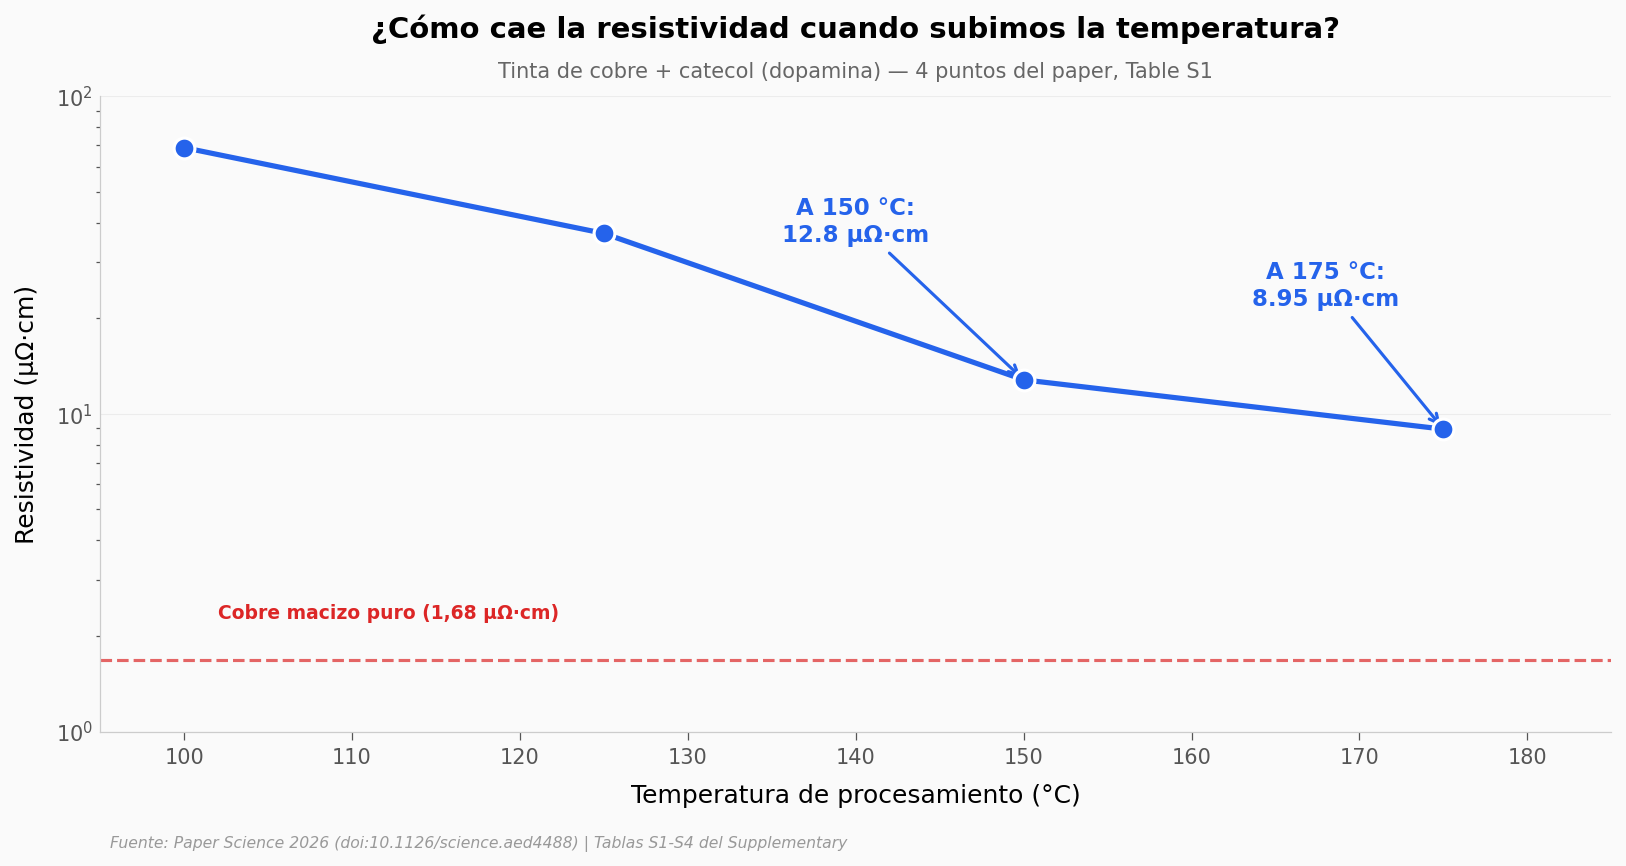

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Curva nuevo metodo
ax.plot(df_resist['temperatura_C'], df_resist['resistividad_uohm_cm'],
        color=COLOR_NUEVO, linewidth=2.5, marker='o', markersize=10,
        markeredgecolor='white', markeredgewidth=1.5, zorder=5)

# Linea de Cu bulk (referencia)
ax.axhline(y=CU_BULK_RESISTIVIDAD, color=COLOR_ALERTA, linewidth=1.5,
           linestyle='--', alpha=0.7)
ax.text(102, CU_BULK_RESISTIVIDAD * 1.35, 'Cobre macizo puro (1,68 µΩ·cm)',
        fontsize=9, color=COLOR_ALERTA, fontweight='bold')

# Anotacion en el punto 150 °C
val_150 = df_resist.loc[df_resist['temperatura_C'] == 150, 'resistividad_uohm_cm'].iloc[0]
ax.annotate(f'A 150 °C:\n{val_150:.1f} µΩ·cm',
            xy=(150, val_150), xytext=(140, 35),
            fontsize=11, fontweight='bold', color=COLOR_NUEVO,
            ha='center',
            arrowprops=dict(arrowstyle='->', color=COLOR_NUEVO, lw=1.5))

# Anotacion en el punto 175 °C
val_175 = df_resist.loc[df_resist['temperatura_C'] == 175, 'resistividad_uohm_cm'].iloc[0]
ax.annotate(f'A 175 °C:\n{val_175:.2f} µΩ·cm',
            xy=(175, val_175), xytext=(168, 22),
            fontsize=11, fontweight='bold', color=COLOR_NUEVO,
            ha='center',
            arrowprops=dict(arrowstyle='->', color=COLOR_NUEVO, lw=1.5))

ax.set_xlabel('Temperatura de procesamiento (°C)')
ax.set_ylabel('Resistividad (µΩ·cm)')
ax.set_yscale('log')
ax.set_xlim(95, 185)
ax.set_ylim(1, 100)
ax.set_title('¿Cómo cae la resistividad cuando subimos la temperatura?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Tinta de cobre + catecol (dopamina) — 4 puntos del paper, Table S1',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/01_resistividad_vs_temperatura.png', dpi=200, bbox_inches='tight')
plt.show()

La caída entre 100 y 175 °C es de **un factor de ~7,7**: pasa de 68,9 a 8,95 µΩ·cm. La pendiente se acentúa entre 125 y 150 °C — ahí es donde las nanopartículas empiezan a fusionarse de verdad y los caminos eléctricos se conectan.

A 175 °C, el material queda a **5,3 veces el cobre macizo puro** (1,68 µΩ·cm, la línea roja). Para un metal impreso desde tinta, sin sinterización prolongada ni atmósfera inerte, eso es excelente. A 150 °C — el umbral que importa para imprimir sobre PET — queda en **12,8 µΩ·cm**.

La pregunta inmediata: ¿cómo se compara con todo lo que se ha publicado antes?

## Comparar contra 30 métodos de literatura

El Supplementary del paper recopila 30 métodos previos de tintas de cobre publicadas, con su temperatura de procesamiento y la resistividad lograda. Cada punto es un paper distinto.

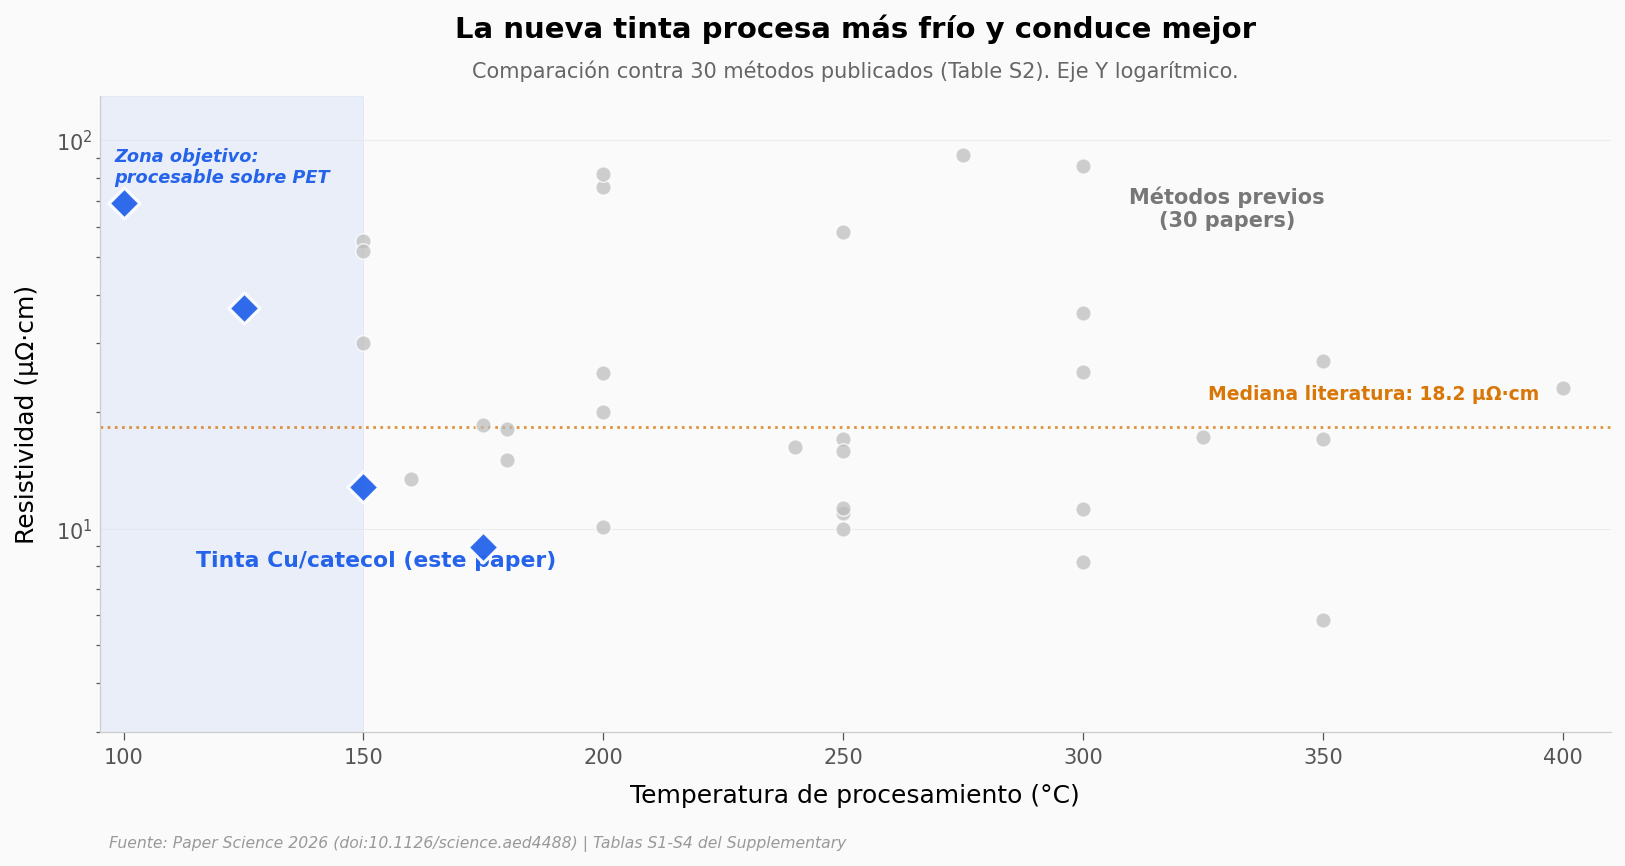

Métodos previos a ≤150 °C: 3/30 (10%)
Métodos previos a ≥250 °C: 17/30 (57%)
Mediana resistividad ≤150 °C: 52.0 µΩ·cm  vs nuevo método: 12,8 µΩ·cm


In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Scatter literatura previa
ax.scatter(df_lit['temperatura_C'], df_lit['resistividad_uohm_cm'],
           color=COLOR_LIT, s=55, alpha=0.7,
           edgecolors='white', linewidths=0.8, zorder=3)

# Nuevo metodo (los 4 puntos)
ax.scatter(df_resist['temperatura_C'], df_resist['resistividad_uohm_cm'],
           color=COLOR_NUEVO, s=110, alpha=0.95,
           edgecolors='white', linewidths=1.5, zorder=6, marker='D')

# Mediana literatura como linea horizontal de referencia
mediana_lit = df_lit['resistividad_uohm_cm'].median()
ax.axhline(y=mediana_lit, color=COLOR_AMBER, linewidth=1.3, linestyle=':', alpha=0.8)
ax.text(395, mediana_lit * 1.18, f'Mediana literatura: {mediana_lit:.1f} µΩ·cm',
        fontsize=9, color=COLOR_AMBER, fontweight='bold', ha='right')

# Inline labels
ax.text(115, 8, 'Tinta Cu/catecol (este paper)',
        fontsize=10.5, color=COLOR_NUEVO, fontweight='bold')
ax.text(330, 60, 'Métodos previos\n(30 papers)',
        fontsize=10, color='#777777', fontweight='bold', ha='center')

# Zona "≤150 °C" sombreada
ax.axvspan(95, 150, alpha=0.08, color=COLOR_NUEVO, zorder=1)
ax.text(98, 78, 'Zona objetivo:\nprocesable sobre PET',
        fontsize=8.5, color=COLOR_NUEVO, fontweight='bold', style='italic')

ax.set_xlabel('Temperatura de procesamiento (°C)')
ax.set_ylabel('Resistividad (µΩ·cm)')
ax.set_yscale('log')
ax.set_xlim(95, 410)
ax.set_ylim(3, 130)
ax.set_title('La nueva tinta procesa más frío y conduce mejor',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Comparación contra 30 métodos publicados (Table S2). Eje Y logarítmico.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/02_comparacion_literatura.png', dpi=200, bbox_inches='tight')
plt.show()

# Estadisticas del rango
n_le_150 = (df_lit['temperatura_C'] <= 150).sum()
n_ge_250 = (df_lit['temperatura_C'] >= 250).sum()
mediana_le150 = df_lit[df_lit['temperatura_C'] <= 150]['resistividad_uohm_cm'].median()
print(f'Métodos previos a ≤150 °C: {n_le_150}/30 ({100*n_le_150/30:.0f}%)')
print(f'Métodos previos a ≥250 °C: {n_ge_250}/30 ({100*n_ge_250/30:.0f}%)')
print(f'Mediana resistividad ≤150 °C: {mediana_le150:.1f} µΩ·cm  vs nuevo método: 12,8 µΩ·cm')

De los 30 métodos publicados, **solo 3 (10%) operan a 150 °C o menos**, y la mediana de esos 3 es **52 µΩ·cm**. El nuevo método entrega 12,8 — **cuatro veces más conductor** a la misma temperatura.

La mayoría de la literatura se concentra entre 200 y 300 °C (mediana global 250 °C). Bajar el umbral a 150 °C abre la puerta a PET, poliimida fina, papel — sustratos donde 250 °C ya empieza a deformar el material.

La siguiente pregunta es por qué. ¿Qué tiene el catecol que el resto de reductores no?

## Por qué catecol gana: simulaciones DFT

El equipo simuló con teoría del funcional de densidad (DFT) la energía de interacción entre un ion Cu⁺ y cinco moléculas distintas que aparecen en tintas de cobre. Energía más negativa = unión más fuerte.

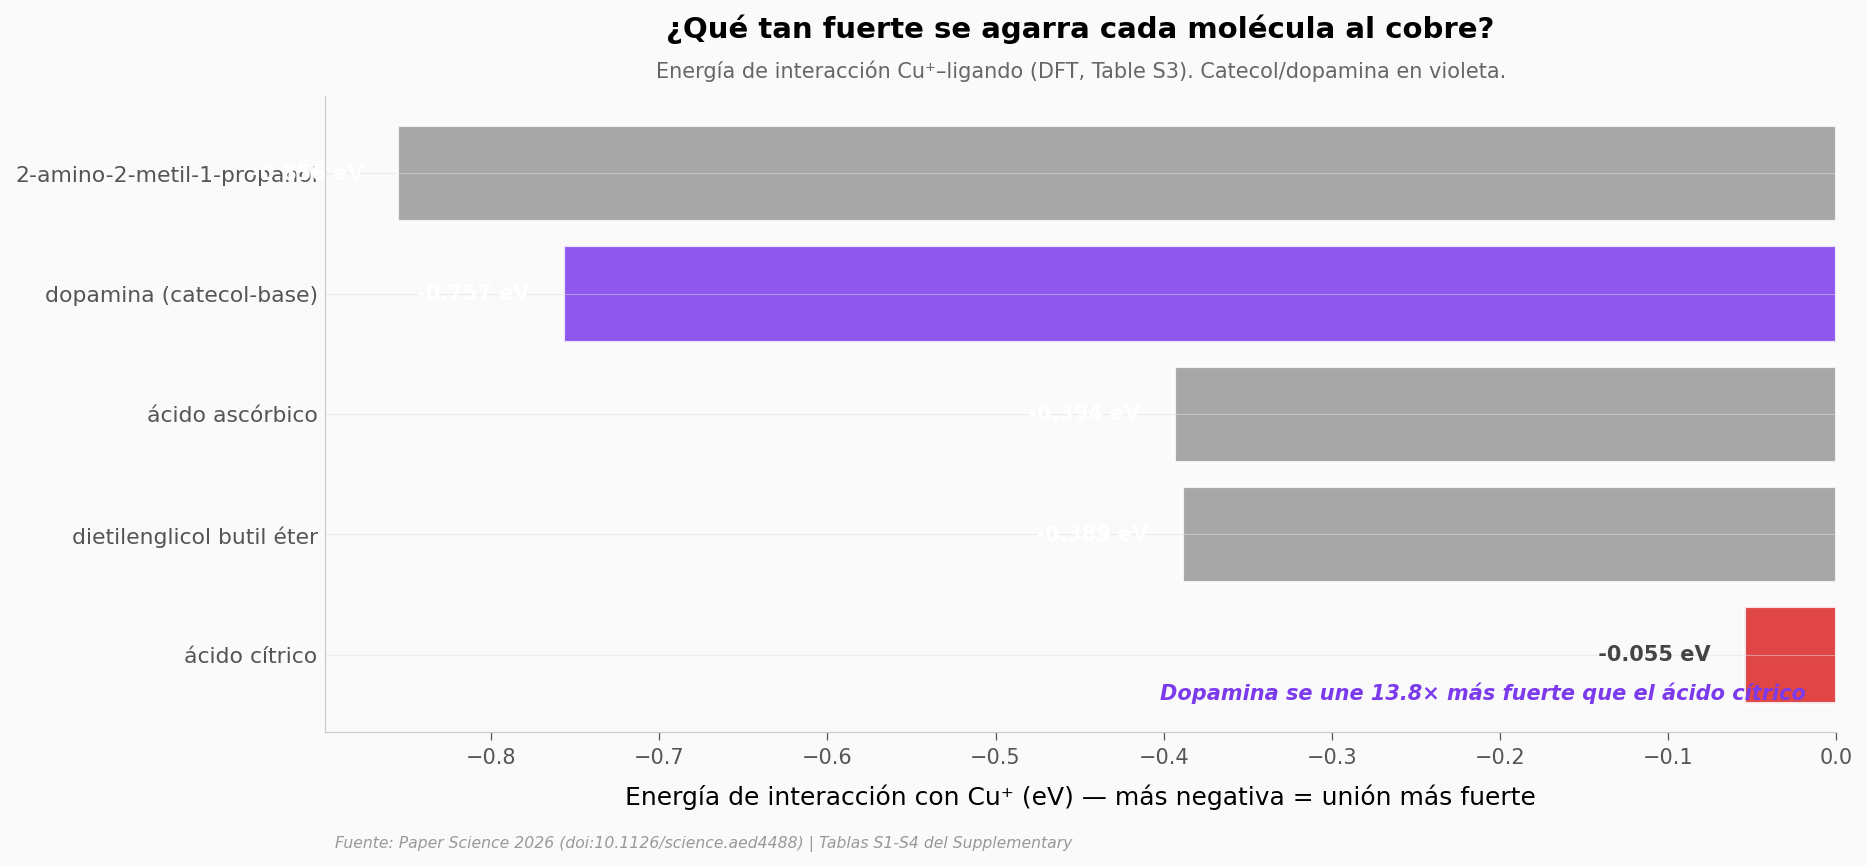

In [4]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Ordenar por energia (mas negativa primero)
df_dft_sorted = df_dft.sort_values('E_interaccion_eV').reset_index(drop=True)

# Resaltar dopamina (catecol-base) en violeta CaM, resto en gris
colores = []
for lig in df_dft_sorted['ligando']:
    if lig == 'DA':
        colores.append(COLOR_VIOLETA)
    elif lig == 'CA':
        colores.append(COLOR_ALERTA)  # ácido cítrico — peor
    else:
        colores.append('#999999')

bars = ax.barh(range(len(df_dft_sorted)), df_dft_sorted['E_interaccion_eV'],
               color=colores, alpha=0.85, edgecolor='white', linewidth=1.5)

# Etiquetas con valores
for i, (val, lig) in enumerate(zip(df_dft_sorted['E_interaccion_eV'],
                                    df_dft_sorted['nombre_completo'])):
    ax.text(val - 0.02, i, f' {val:.3f} eV',
            ha='right', va='center', fontsize=10, fontweight='bold',
            color='white' if abs(val) > 0.3 else '#444444')

ax.set_yticks(range(len(df_dft_sorted)))
ax.set_yticklabels(df_dft_sorted['nombre_completo'], fontsize=10.5)
ax.set_xlabel('Energía de interacción con Cu⁺ (eV) — más negativa = unión más fuerte')

# Anotacion comparativa
ratio = df_dft_sorted.loc[df_dft_sorted['ligando']=='DA','E_interaccion_eV'].iloc[0] / \
        df_dft_sorted.loc[df_dft_sorted['ligando']=='CA','E_interaccion_eV'].iloc[0]
ax.text(0.98, 0.05,
        f'Dopamina se une {ratio:.1f}× más fuerte que el ácido cítrico',
        transform=ax.transAxes, fontsize=10, color=COLOR_VIOLETA,
        fontweight='bold', ha='right', style='italic')

ax.invert_yaxis()  # mas fuerte arriba
ax.set_title('¿Qué tan fuerte se agarra cada molécula al cobre?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Energía de interacción Cu⁺–ligando (DFT, Table S3). Catecol/dopamina en violeta.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/03_dft_energias_interaccion.png', dpi=200, bbox_inches='tight')
plt.show()

**El 2-amino-2-metil-1-propanol (AMP) se agarra incluso más fuerte que la dopamina** (-0,856 vs -0,757 eV) — es la base de la tinta que solubiliza el cobre. La dopamina entra en segundo lugar, pero con una propiedad que las demás no tienen: **el grupo catecol puede reducir Cu²⁺ a Cu(0)** mientras se oxida a quinona. AMP solo coordina; catecol coordina **y** reduce.

El ácido cítrico — un reductor clásico en tintas verdes — apenas marca **-0,055 eV**. Catorce veces menos que dopamina. Esa diferencia es la razón de que el catecol nuclee partículas de cobre tan reactivas a baja temperatura.

¿Y cómo lucen esas partículas por dentro?

## ¿Qué tan inusual es esta resistividad?

Una forma de cuantificar lo que pasa: poner la nueva resistividad sobre la distribución completa de la literatura, y ver dónde cae.

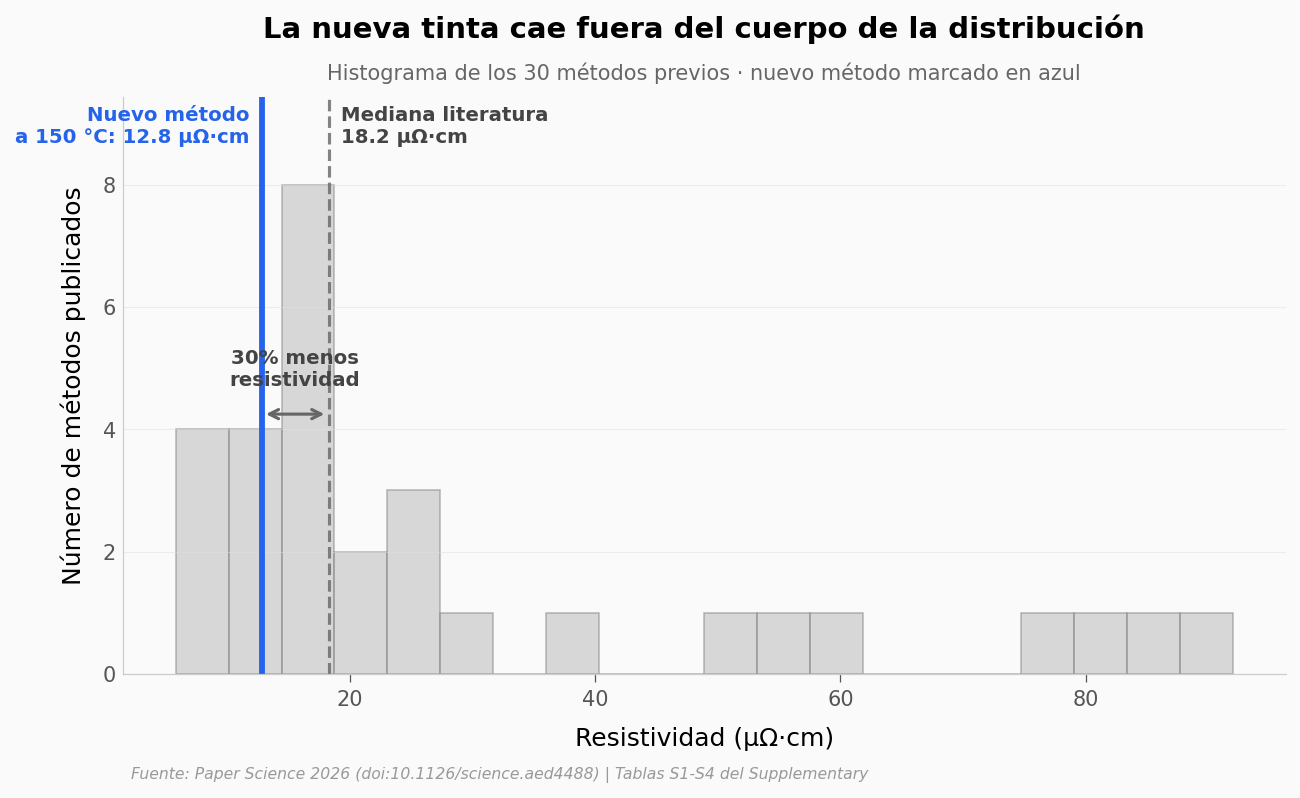

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

# Histograma de toda la literatura
n, bins, patches = ax.hist(df_lit['resistividad_uohm_cm'], bins=20,
                            color=COLOR_LIT, alpha=0.55,
                            edgecolor='#888888', linewidth=0.8)
y_max = n.max() * 1.18
ax.set_ylim(0, y_max)

# Mediana literatura
med = df_lit['resistividad_uohm_cm'].median()
ax.axvline(x=med, color='#666666', linewidth=1.5, linestyle='--', alpha=0.8)
ax.text(med + 1, y_max * 0.92,
        f'Mediana literatura\n{med:.1f} µΩ·cm',
        fontsize=9.5, color='#444444', fontweight='bold')

# Nuevo metodo a 150 °C
ax.axvline(x=RESISTIVIDAD_NUEVO_150, color=COLOR_NUEVO, linewidth=2.8)
ax.text(RESISTIVIDAD_NUEVO_150 - 1, y_max * 0.92,
        f'Nuevo método\na 150 °C: {RESISTIVIDAD_NUEVO_150:.1f} µΩ·cm',
        fontsize=9.5, color=COLOR_NUEVO, fontweight='bold', ha='right')

# Flecha bidireccional
ax.annotate('', xy=(RESISTIVIDAD_NUEVO_150, y_max * 0.45),
            xytext=(med, y_max * 0.45),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
diff_pct = 100 * (med - RESISTIVIDAD_NUEVO_150) / med
ax.text((med + RESISTIVIDAD_NUEVO_150) / 2, y_max * 0.50,
        f'{diff_pct:.0f}% menos\nresistividad',
        ha='center', fontsize=9.5, color='#444444', fontweight='bold')

ax.set_xlabel('Resistividad (µΩ·cm)')
ax.set_ylabel('Número de métodos publicados')
ax.set_title('La nueva tinta cae fuera del cuerpo de la distribución',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'Histograma de los 30 métodos previos · nuevo método marcado en azul',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/04_histograma_anomalia.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|:-----------:|---------|
| Procesamiento a 150 °C es viable | ✅ | Table S1: la curva muestra 12,8 µΩ·cm a 150 °C, dos órdenes de magnitud por debajo del óxido. |
| Resistividad <10 µΩ·cm a 175 °C | ✅ | Table S1: 8,95 µΩ·cm a 175 °C (5,3× el cobre macizo). |
| Mejora ~4× vs literatura a 150 °C | ✅ | Table S2: 3 métodos previos operan a ≤150 °C, mediana 52 µΩ·cm. Nuevo: 12,8. |
| Catecol/dopamina es el reductor clave | ✅ con matiz | Table S3: E_int(DA) = -0,757 eV vs CA -0,055 eV. AMP es aún más fuerte (-0,856) pero solo coordina; dopamina coordina **y** reduce. |
| Estabilidad >1000 h en ácido, >200 h en sulfuro, >240 h a 140 °C | ⚠️ Reportada, no graficada | Cifras del abstract — los datos de cinéticas viven en las Figs del paper, no en las Tablas S1-S4 que extrajimos. |
| Imprimible sobre plásticos flexibles | ⚠️ Inferencia razonable | El paper muestra impresión sobre PET; los datos cuantitativos están en las figuras que no extrajimos. |

> **Limitaciones del análisis.** Trabajamos con las Tablas S1-S4 del Supplementary (curva resistividad-temperatura, 30 métodos de literatura, energías DFT, estructura EXAFS). Las gráficas de cinética de corrosión y los datos de impresión sobre sustratos viven en las figuras del paper — el material gráfico no es trivialmente extractable, así que esas afirmaciones las citamos del abstract pero no las verificamos numéricamente.

## Ahora tú

Tres preguntas para abrir los datos por tu cuenta:

1. **¿Cuánto más conduce el nuevo método comparado con cada uno de los 30 métodos previos a su misma temperatura?** Pista: para cada fila de `df_lit`, busca el punto más cercano de `df_resist` en temperatura y calcula el ratio.
2. **¿La fuerza de unión DFT predice la conductividad final?** Pista: solo tenemos 5 ligandos en DFT, pero el orden cualitativo es informativo. ¿AMP sería un buen reductor a juzgar por su energía?
3. **¿Qué pasa si extrapolas la curva a temperatura ambiente (25 °C)?** Pista: ajusta una exponencial a los 4 puntos y mira qué predice. ¿Tiene sentido físico?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: ¿Cuál es el ratio de conductividad del nuevo método vs literatura
#             a su misma temperatura?

# Para cada fila de literatura, busca el punto de resistividad mas cercano en temperatura
def resist_nuevo_a_T(temp_C):
    """Interpola la resistividad del nuevo metodo a una temperatura dada."""
    return np.interp(temp_C, df_resist['temperatura_C'], df_resist['resistividad_uohm_cm'])

df_comp = df_lit[['n', 'temperatura_C', 'resistividad_uohm_cm']].copy()
df_comp = df_comp.dropna(subset=['resistividad_uohm_cm'])
df_comp = df_comp[df_comp['temperatura_C'].between(100, 175)]  # solo donde podemos interpolar
df_comp['resist_nuevo_a_misma_T'] = df_comp['temperatura_C'].apply(resist_nuevo_a_T)
df_comp['ratio_lit_vs_nuevo'] = df_comp['resistividad_uohm_cm'] / df_comp['resist_nuevo_a_misma_T']

print('Comparación a la misma temperatura (solo métodos previos entre 100-175 °C):')
print()
print(df_comp.sort_values('ratio_lit_vs_nuevo', ascending=False)[
    ['n', 'temperatura_C', 'resistividad_uohm_cm', 'resist_nuevo_a_misma_T', 'ratio_lit_vs_nuevo']
].to_string(index=False))
print()
print(f'Mejora mediana del nuevo método: {df_comp["ratio_lit_vs_nuevo"].median():.1f}× a igual temperatura')

Comparación a la misma temperatura (solo métodos previos entre 100-175 °C):

 n  temperatura_C  resistividad_uohm_cm  resist_nuevo_a_misma_T  ratio_lit_vs_nuevo
10            150                  55.0                   12.80            4.296875
20            150                  52.0                   12.80            4.062500
19            150                  30.0                   12.80            2.343750
21            175                  18.5                    8.95            2.067039
27            160                  13.4                   11.26            1.190053

Mejora mediana del nuevo método: 2.3× a igual temperatura


## Fuentes

**Paper**: [A molecular pathway to corrosion-resistant printable copper](https://doi.org/10.1126/science.aed4488)  
*Science, 2026-05-14*

**Supplementary Material**: [A molecular pathway to corrosion-resistant printable copper — Supplementary Materials (Figs. S1-S63, Tables S1-S4)](https://www.science.org/doi/suppl/10.1126/science.aed4488/suppl_file/science.aed4488_sm.pdf)  
*Tablas S1-S4 (curva resistividad-temperatura, 30 métodos de literatura, energías DFT, EXAFS)*

*25 afirmaciones del notebook verificadas contra estas fuentes*

---

**Repo:** [Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) · **Licencia notebook:** CC-BY 4.0